# Exploratory Data Analysis & Feature Extraction for Mobile Phones - NHIS Project 3

In [2]:
# importing modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("dataset/Processed_Flipdata - Processed_Flipdata.csv")
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


In [4]:
# drop col 0
df = df.drop(columns=['Unnamed: 0'])
df.head()

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


In [5]:
shape = df.shape
print(f"This dataset contains {shape[0]} rows & {shape[1]} columns")

This dataset contains 541 rows & 11 columns


### Basic Cleaning

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          541 non-null    str    
 1   Colour         541 non-null    str    
 2   Memory         541 non-null    int64  
 3   RAM            541 non-null    int64  
 4   Battery_       541 non-null    int64  
 5   Rear Camera    541 non-null    str    
 6   Front Camera   541 non-null    str    
 7   AI Lens        541 non-null    int64  
 8   Mobile Height  541 non-null    float64
 9   Processor_     541 non-null    str    
 10  Prize          541 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 46.6 KB


In [7]:
# dropping 10 containing duplicates
print("Before dropping:", df.duplicated().sum())
df = df.drop_duplicates()
print("After dropping:", df.duplicated().sum())

Before dropping: 10
After dropping: 0


>Insight: There are no missing values found in all columns. But, There are 10 duplicate columns found

In [8]:
# handling AI Lens column - boolean to categorical
df['AI Lens'] = np.where(df['AI Lens'] == 0, "No", "Yes")
df['AI Lens'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [9]:
# handling Rear Camera - cat to num
df['Rear Camera'] = df['Rear Camera'].str.replace('MP', '', case=False).astype(int)
df['Rear Camera'].unique()

array([ 13,  50,   8,  40,  32,  48,  64, 108,   0,   2,  12, 200,   5,
        16])

In [10]:
# handling Front Camera - cat to num
df['Front Camera'] = df['Front Camera'].str.replace('MP', '', case=False).astype(int)
df['Front Camera'].unique()

array([ 5, 16,  8, 13,  0, 32, 10, 50, 60, 20, 44,  2, 12])

In [11]:
# fixing price column to integer
df['Prize'] = df['Prize'].str.replace(',', '', case=False).astype(int)

In [12]:
df.head()

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,Infinix SMART 7,Night Black,64,4,6000,13,5,Yes,16.76,Unisoc Spreadtrum SC9863A1,7299
1,Infinix SMART 7,Azure Blue,64,4,6000,13,5,Yes,16.76,Unisoc Spreadtrum SC9863A1,7299
2,MOTOROLA G32,Mineral Gray,128,8,5000,50,16,No,16.64,Qualcomm Snapdragon 680,11999
3,POCO C50,Royal Blue,32,2,5000,8,5,No,16.56,Mediatek Helio A22,5649
4,Infinix HOT 30i,Marigold,128,8,5000,50,5,Yes,16.76,G37,8999


### 1. Univariate Analysis

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Memory,531.0,110.915254,60.872883,16.0,64.00,128.00,128.00,256.00
RAM,531.0,5.401130,1.991283,2.0,4.00,6.00,8.00,8.00
Battery_,531.0,4873.877589,765.883129,800.0,5000.00,5000.00,5000.00,7000.00
Rear Camera,531.0,46.227872,31.392146,0.0,13.00,50.00,50.00,200.00
Front Camera,531.0,12.045198,9.105142,0.0,5.00,8.00,16.00,60.00
Mobile Height,531.0,16.450019,2.494246,4.5,16.51,16.71,16.94,41.94
Prize,531.0,16305.775895,10847.038354,920.0,9368.00,13999.00,19338.50,80999.00


- ### Numerical

Memory
128    254
64     165
256     55
32      52
16       5
Name: count, dtype: int64

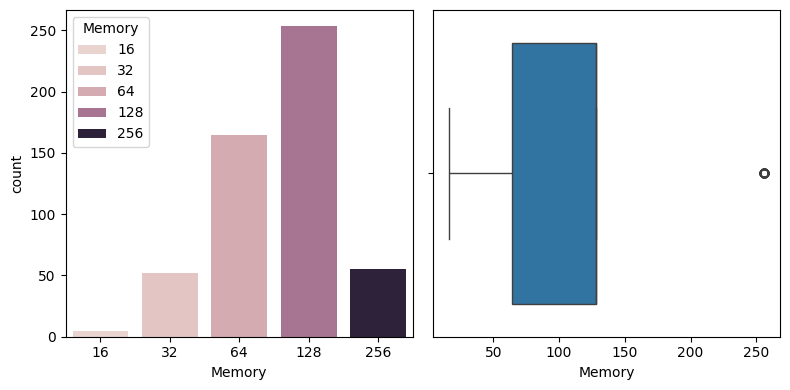

In [14]:
# Memory
display(df['Memory'].value_counts())

fig = plt.figure(figsize=(8, 4))

# Countplot
plt.subplot(1, 2, 1)
ax = sns.countplot(data=df, x='Memory', hue='Memory')

# Boxplot
plt.subplot(1, 2, 2)
bx = sns.boxplot(data=df, x='Memory')

plt.tight_layout()
plt.show()

>Insights

RAM
4    180
8    155
6    119
3     40
2     37
Name: count, dtype: int64

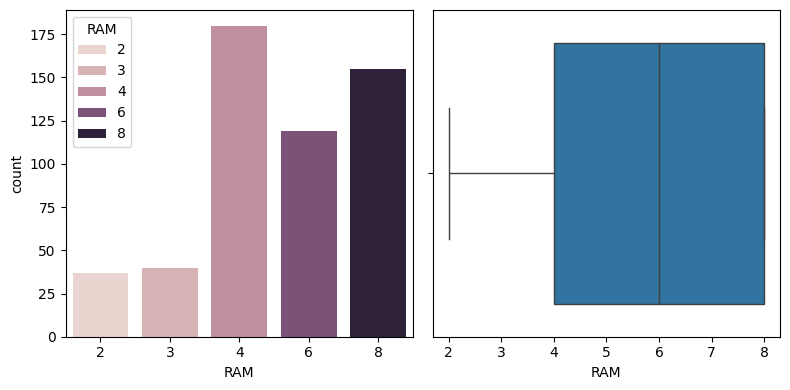

In [15]:
# RAM
display(df['RAM'].value_counts())

fig = plt.figure(figsize=(8, 4))

# Countplot
plt.subplot(1, 2, 1)
ax = sns.countplot(data=df, x='RAM', hue='RAM')

# Boxplot
plt.subplot(1, 2, 2)
bx = sns.boxplot(data=df, x='RAM')

plt.tight_layout()
plt.show()

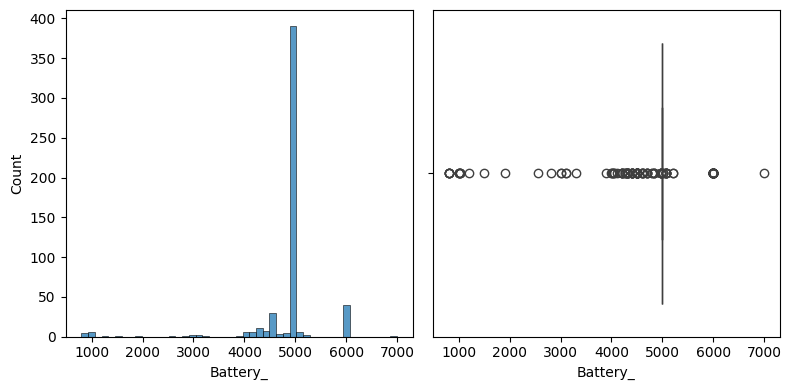

In [17]:
# Battery
# display(df['Battery_'].value_counts())

fig = plt.figure(figsize=(8, 4))

# Countplot
plt.subplot(1, 2, 1)
ax = sns.histplot(data=df, x='Battery_', legend=False)

# Boxplot
plt.subplot(1, 2, 2)
bx = sns.boxplot(data=df, x='Battery_')

plt.tight_layout()
plt.show()

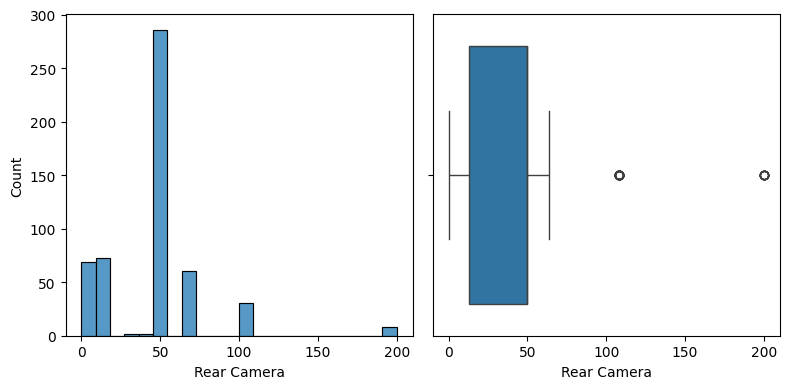

In [20]:
# Rear Camera
# display(df['Rear Camera'].value_counts())

fig = plt.figure(figsize=(8, 4))

# Countplot
plt.subplot(1, 2, 1)
ax = sns.histplot(data=df, x='Rear Camera', legend=False)

# Boxplot
plt.subplot(1, 2, 2)
bx = sns.boxplot(data=df, x='Rear Camera')

plt.tight_layout()
plt.show()